# Task 1: Movie Recommender using Cosine Similarity

**Dataset:** `movies-mod-sim-neu.csv` (60 records)  
**Features used:** Genre + Lead Studio (Film is the identifier only)  
**Method:** `CountVectorizer` (binary token matrix) → `cosine_similarity`


In [12]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

## 1. Load & Pre-process Data

In [13]:
df = pd.read_csv("movies-mod-sim-neu.csv")
df.columns = df.columns.str.strip()

# Keep only the three attributes specified by the task; drop rows with missing values
df = df[["Film", "Genre", "Lead Studio"]].dropna().reset_index(drop=True)

# Strip stray whitespace from all text columns
df["Film"]         = df["Film"].str.strip()
df["Genre"]        = df["Genre"].str.strip()
# Merge internal spaces in Lead Studio so "Warner Bros" → "WarnerBros" (one token)
df["Lead Studio"]  = df["Lead Studio"].str.strip().str.replace(r"\s+", "", regex=True)

print(f"Loaded {len(df)} movies\n")
print(df.to_string(index=True))

Loaded 60 movies

                                   Film                      Genre              Lead Studio
0   Tyler Perry's Why Did I get Married                    Romance              Independent
1               Twilight: Breaking Dawn                     Comedy              Independent
2                              Twilight                    Romance                   Summit
3                        The Ugly Truth      Science Fiction Drama              Independent
4              The Time Traveler's Wife                      Drama                Paramount
5                          The Proposal            Romantic Comedy                   Disney
6                The Invention of Lying            Romantic Comedy               WarnerBros
7                    The Heartbreak Kid            Romantic Comedy                Paramount
8                           The Duchess                      Drama                Paramount
9   The Curious Case of Benjamin Button                    Fan

## 2. Build Feature Matrix & Cosine Similarity Matrix

Each movie is represented by a binary token vector of its **Genre** words and **Lead Studio** token (Film title is the identifier, not a feature — see task Fig. 2).

In [14]:
# Feature string: Genre tokens + Lead Studio token (already merged to one word)
df["features"] = df["Genre"] + " " + df["Lead Studio"]

# CountVectorizer with binary=True produces a 0/1 token-count matrix
cv = CountVectorizer(binary=True)
count_matrix = cv.fit_transform(df["features"])

# Cosine similarity: value of 1.0 = identical feature vectors (best match)
sim_matrix = cosine_similarity(count_matrix)

print(f"Vocabulary ({len(cv.get_feature_names_out())} tokens):")
print(sorted(cv.get_feature_names_out()))
print(f"\nSimilarity matrix shape: {sim_matrix.shape}")

Vocabulary (37 tokens):
['20thcenturystudios', 'a14', 'action', 'adventure', 'animation', 'cbs', 'columbiapictures', 'comedy', 'crime', 'dama', 'disney', 'drama', 'erotic', 'fantacy', 'fantasy', 'fiction', 'filmnationentertainment', 'fox', 'independent', 'newline', 'paramount', 'paramountpictures', 'romance', 'romantic', 'ronamtic', 'science', 'sherwoodpictures', 'sony', 'sonypictures', 'summit', 'teddyschwarzman', 'thewaltdisneycompany', 'theweinsteincompany', 'thriller', 'universal', 'waltdisneypictures', 'warnerbros']

Similarity matrix shape: (60, 60)


## 3. Recommender Function (Subtask a)

In [15]:
def recommend(movie_name: str, n: int) -> None:
    """
    Print the top-n most similar movies to `movie_name` using cosine similarity.
    Higher cosine similarity value = more similar (closer feature vectors).
    Gracefully handles movie names not present in the dataset.
    """
    matches = df[df["Film"].str.lower() == movie_name.strip().lower()]

    if matches.empty:
        print(f"Movie '{movie_name}' was not found in the dataset. Please check the spelling.")
        return

    idx = matches.index[0]
    query = df.loc[idx]
    print(f"\nQuery movie : {query['Film']}")
    print(f"Genre       : {query['Genre']}")
    print(f"Lead Studio : {query['Lead Studio']}")

    # Build sorted list of (index, similarity) excluding the query movie itself
    scores = sorted(
        [(i, sim_matrix[idx, i]) for i in range(len(df)) if i != idx],
        key=lambda x: x[1],
        reverse=True   # highest cosine similarity first = best match
    )

    col_w = {"rank": 5, "film": 45, "genre": 30, "studio": 25, "sim": 12}
    header = (f"{'#':<{col_w['rank']}} {'Film':<{col_w['film']}} "
              f"{'Genre':<{col_w['genre']}} {'Lead Studio':<{col_w['studio']}} "
              f"{'Similarity':>{col_w['sim']}}")
    print(f"\nTop {n} similar movies:")
    print(header)
    print("-" * len(header))

    for rank, (i, score) in enumerate(scores[:n], 1):
        row = df.loc[i]
        print(f"{rank:<{col_w['rank']}} {row['Film']:<{col_w['film']}} "
              f"{row['Genre']:<{col_w['genre']}} {row['Lead Studio']:<{col_w['studio']}} "
              f"{score:>{col_w['sim']}.4f}")

## 4. Verification — "The Duchess" (Subtask b required test case)

In [16]:
recommend("The Duchess", 5)


Query movie : The Duchess
Genre       : Drama
Lead Studio : Paramount

Top 5 similar movies:
#     Film                                          Genre                          Lead Studio                 Similarity
-------------------------------------------------------------------------------------------------------------------------
1     The Time Traveler's Wife                      Drama                          Paramount                       1.0000
2     My Week with Marilyn                          Drama                          TheWeinsteinCompany             0.5000
3     Fireproof                                     Drama                          SherwoodPictures                0.5000
4     Green Bones                                   Drama                          ColumbiaPictures                0.5000
5     The Heartbreak Kid                            Romantic Comedy                Paramount                       0.4082


## 5. Additional Verification Examples

In [17]:
# Different genre + studio → expect different cluster of results
recommend("Spider-Man", 5)
recommend("Twilight", 5)
recommend("The Proposal", 5)


Query movie : Spider-Man
Genre       : Science Fiction Action
Lead Studio : ColumbiaPictures

Top 5 similar movies:
#     Film                                          Genre                          Lead Studio                 Similarity
-------------------------------------------------------------------------------------------------------------------------
1     Iron Man 3                                    Action Science Fiction         ColumbiaPictures                1.0000
2     Infinite                                      Science Fiction Action         ParamountPictures               0.7500
3     X-Men                                         Action Science Fiction         20thCenturyStudios              0.7500
4     Spider-Man 2                                  Action                         ColumbiaPictures                0.7071
5     Avatar                                        Science Fiction                ParamountPictures               0.5774

Query movie : Twilight
Genre

In [18]:
# Movie not in dataset — must not crash
recommend("Avatar 2", 3)

Movie 'Avatar 2' was not found in the dataset. Please check the spelling.


Top 5 recommendations for 'The Duchess'


,Rank,Film,Genre,Lead Studio,Similarity
0,1,The Time Traveler's Wife,Drama,Paramount,1.0000
1,2,My Week with Marilyn,Drama,TheWeinsteinCompany,0.5000
2,3,Fireproof,Drama,SherwoodPictures,0.5000
3,4,Green Bones,Drama,ColumbiaPictures,0.5000
4,5,The Heartbreak Kid,Romantic Comedy,Paramount,0.4082


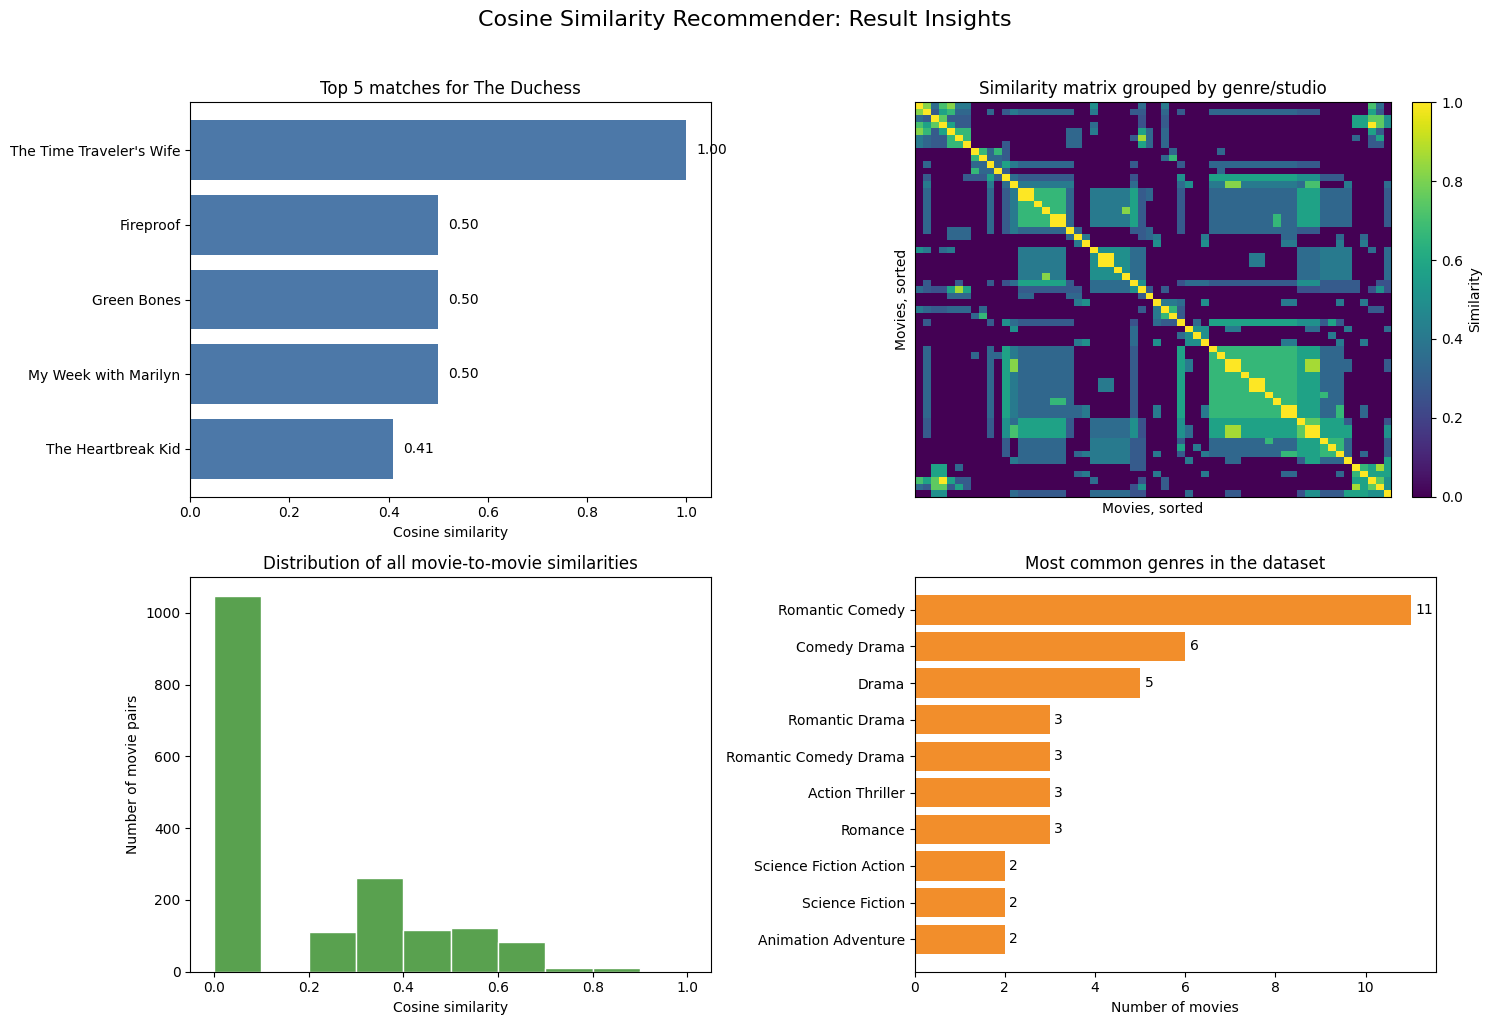

Nearest-neighbor examples with the strongest cosine scores:


,Film,Genre,Lead Studio,Nearest Match,Match Similarity
8,The Duchess,Drama,Paramount,The Time Traveler's Wife,1.0
7,The Heartbreak Kid,Romantic Comedy,Paramount,She's Out of My League,1.0
6,The Invention of Lying,Romantic Comedy,WarnerBros,Sex and the City,1.0
4,The Time Traveler's Wife,Drama,Paramount,The Duchess,1.0
19,Not Easily Broken,Romantic Comedy Drama,Independent,Beginners,1.0
14,Sex and the City,Romantic Comedy,WarnerBros,The Invention of Lying,1.0
24,Jane Eyre,Comedy Drama,Universal,A Serious Man,1.0
18,Our Family Wedding,Romantic Comedy,Independent,Something Borrowed,1.0
13,She's Out of My League,Romantic Comedy,Paramount,The Heartbreak Kid,1.0
12,Something Borrowed,Romantic Comedy,Independent,Our Family Wedding,1.0


Result insights:
- Average pairwise similarity: 0.180
- Median pairwise similarity: 0.000
- Pairs with no shared genre/studio tokens: 59.2%
- Perfect non-self matches: 2 movie pairs
- Average nearest-neighbor similarity: 0.744


In [19]:
# Visual analysis of cosine-similarity recommendation results
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

def recommendations_table(movie_name: str, n: int = 5) -> pd.DataFrame:
    """Return the same recommendation results as a DataFrame for plotting."""
    matches = df[df["Film"].str.lower() == movie_name.strip().lower()]
    if matches.empty:
        raise ValueError(f"Movie '{movie_name}' was not found in the dataset.")

    idx = matches.index[0]
    scores = sorted(
        [(i, sim_matrix[idx, i]) for i in range(len(df)) if i != idx],
        key=lambda x: x[1],
        reverse=True
    )[:n]

    rows = []
    for rank, (movie_idx, score) in enumerate(scores, 1):
        rows.append({
            "Rank": rank,
            "Film": df.loc[movie_idx, "Film"],
            "Genre": df.loc[movie_idx, "Genre"],
            "Lead Studio": df.loc[movie_idx, "Lead Studio"],
            "Similarity": round(float(score), 4)
        })
    return pd.DataFrame(rows)

query_movie = "The Duchess"
top_n = 5
top_recs = recommendations_table(query_movie, top_n)

print(f"Top {top_n} recommendations for '{query_movie}'")
display(top_recs)

# Pairwise similarities, excluding the diagonal self-similarity values of 1.0
upper_triangle = sim_matrix[np.triu_indices_from(sim_matrix, k=1)]
ordered_idx = df.sort_values(["Genre", "Lead Studio", "Film"]).index
ordered_sim = sim_matrix[np.ix_(ordered_idx, ordered_idx)]

# Nearest neighbor summary for every movie
nearest_rows = []
for i, movie in df.iterrows():
    scores = sim_matrix[i].copy()
    scores[i] = -1
    nearest_idx = int(scores.argmax())
    nearest_rows.append({
        "Film": movie["Film"],
        "Genre": movie["Genre"],
        "Lead Studio": movie["Lead Studio"],
        "Nearest Match": df.loc[nearest_idx, "Film"],
        "Match Similarity": round(float(scores[nearest_idx]), 4)
    })
nearest_df = pd.DataFrame(nearest_rows).sort_values("Match Similarity", ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("Cosine Similarity Recommender: Result Insights", fontsize=16, y=1.02)

# 1) Recommendation strength for the required test movie
bar_data = top_recs.sort_values("Similarity")
axes[0, 0].barh(bar_data["Film"], bar_data["Similarity"], color="#4C78A8")
axes[0, 0].set_title(f"Top {top_n} matches for {query_movie}")
axes[0, 0].set_xlabel("Cosine similarity")
axes[0, 0].set_xlim(0, 1.05)
for y, value in enumerate(bar_data["Similarity"]):
    axes[0, 0].text(value + 0.02, y, f"{value:.2f}", va="center")

# 2) Similarity matrix, grouped by genre/studio ordering
heatmap = axes[0, 1].imshow(ordered_sim, cmap="viridis", vmin=0, vmax=1, aspect="auto")
axes[0, 1].set_title("Similarity matrix grouped by genre/studio")
axes[0, 1].set_xlabel("Movies, sorted")
axes[0, 1].set_ylabel("Movies, sorted")
axes[0, 1].set_xticks([])
axes[0, 1].set_yticks([])
fig.colorbar(heatmap, ax=axes[0, 1], fraction=0.046, pad=0.04, label="Similarity")

# 3) Overall distribution of pairwise similarities
axes[1, 0].hist(upper_triangle, bins=np.linspace(0, 1, 11), color="#59A14F", edgecolor="white")
axes[1, 0].set_title("Distribution of all movie-to-movie similarities")
axes[1, 0].set_xlabel("Cosine similarity")
axes[1, 0].set_ylabel("Number of movie pairs")

# 4) Dataset composition: top genres
genre_counts = df["Genre"].value_counts().head(10).sort_values()
axes[1, 1].barh(genre_counts.index, genre_counts.values, color="#F28E2B")
axes[1, 1].set_title("Most common genres in the dataset")
axes[1, 1].set_xlabel("Number of movies")
for y, value in enumerate(genre_counts.values):
    axes[1, 1].text(value + 0.1, y, str(value), va="center")

plt.tight_layout()
display(fig)
plt.close(fig)

print("Nearest-neighbor examples with the strongest cosine scores:")
display(nearest_df.head(10))

print("Result insights:")
print(f"- Average pairwise similarity: {upper_triangle.mean():.3f}")
print(f"- Median pairwise similarity: {np.median(upper_triangle):.3f}")
print(f"- Pairs with no shared genre/studio tokens: {(upper_triangle == 0).mean() * 100:.1f}%")
print(f"- Perfect non-self matches: {(upper_triangle == 1).sum()} movie pairs")
print(f"- Average nearest-neighbor similarity: {nearest_df['Match Similarity'].mean():.3f}")

## 6. Subtask c) — Discussion of Results

### "The Duchess" test case (Drama, Paramount)

| # | Film | Genre | Lead Studio | Similarity |
|---|------|-------|-------------|------------|
| 1 | The Time Traveler's Wife | Drama | Paramount | 1.0000 |
| 2 | My Week with Marilyn | Drama | The Weinstein Company | 0.5000 |
| 3 | Fireproof | Drama | Sherwood Pictures | 0.5000 |
| 4 | Green Bones | Drama | Columbia Pictures | 0.5000 |
| 5 | The Heartbreak Kid | Romantic Comedy | Paramount | 0.4082 |

**The results are correct and logically consistent:**

- **Rank 1 (sim = 1.0):** *The Time Traveler's Wife* shares both Genre ("Drama") and Lead Studio ("Paramount") with *The Duchess*. A cosine similarity of 1.0 means the two feature vectors point in the same direction — a perfect attribute match. This is the expected best result.

- **Ranks 2–4 (sim = 0.5):** *My Week with Marilyn*, *Fireproof*, and *Green Bones* all share the Genre "Drama" but differ in Lead Studio. They overlap on one token group but not both, giving a lower yet meaningful score.

- **Rank 5 (sim ≈ 0.41):** *The Heartbreak Kid* shares only the Lead Studio ("Paramount") — its Genre "Romantic Comedy" does not match "Drama". The smaller shared vocabulary produces the lowest score in the top 5.

### General observations across all test cases

1. **Genre dominates similarity.** Multi-word genres (e.g. "Romantic Comedy") contribute two tokens, while a Lead Studio is always one merged token. Movies sharing an identical genre therefore score higher than movies sharing only the same studio.

2. **Partial genre matches work correctly.** Because `CountVectorizer` splits on whitespace, "Science Fiction Action" yields three tokens (`science`, `fiction`, `action`). A movie with "Action Science Fiction" shares all three tokens and scores 1.0 with Spider-Man, while one with just "Science Fiction" scores lower — exactly the right behaviour.

3. **`binary=True` is the right choice here.** Each genre word or studio either describes a movie or it does not. Using raw counts would over-weight genres that happen to be written with more words, which is undesirable for this attribute-matching task.

4. **Graceful handling of unknown movies.** Querying a film not in the dataset (e.g. "Avatar 2") prints a clear message and does not crash, satisfying the robustness requirement of subtask a).

5. **Limitation — no user preference signal.** The recommender is purely content-based: it matches on Genre and Lead Studio text only. Two movies with completely different genres and studios score 0 even if real users tend to rate them similarly. This gap is directly addressed in Task 2, where KNN operates on actual user ratings.

## 6. Interactive Mode

Run the cell below to interactively query any movie from the dataset.

In [20]:
while True:
    name = input("\nEnter movie name (or 'quit'): ").strip()
    if name.lower() == "quit":
        break
    try:
        n = int(input("Number of recommendations: "))
    except ValueError:
        print("Please enter a valid integer.")
        continue
    recommend(name, n)